# Klein et al. (2017) – Droplet Barcoding for Single-Cell Transcriptomics Applied to Embryonic Stem Cells

The original paper can be found here: https://www.sciencedirect.com/science/article/pii/S0092867415005000

__Abstract__: It has long been the dream of biologists to map gene expression at the single-cell level. With such data one might track heterogeneous cell sub-populations, and infer regulatory relationships between genes and pathways. Recently, RNA sequencing has achieved single-cell resolution. What is limiting is an effective way to routinely isolate and process large numbers of individual cells for quantitative in-depth sequencing. We have developed a high-throughput droplet-microfluidic approach for barcoding the RNA from thousands of individual cells for subsequent analysis by next-generation sequencing. The method shows a surprisingly low noise profile and is readily adaptable to other sequencing-based assays. We analyzed mouse embryonic stem cells, revealing in detail the population structure and the heterogeneous onset of differentiation after leukemia inhibitory factor (LIF) withdrawal. The reproducibility of these high-throughput single-cell data allowed us to deconstruct cell populations and infer gene expression relationships.

Klein et al. analyze 2,717 single cells. The 4 classes in which they mention are experimental conditions/timepoints:

What the 4 classes are
- 0 days (baseline mESCs, +LIF)
- 2 days after LIF withdrawal
- 4 days after LIF withdrawal
- 7 days after LIF withdrawal

Klein profiled mESCs before and after LIF withdrawal to study early differentiation dynamics; GEO lists data for baseline ES cells and LIF− at days 2, 4, 7, which are the four-condition split many benchmarks (incl. scMINER) use.

---

## 0. Imports & Configuration

In [1]:
from pathlib import Path
import sys

repo_root = Path.cwd().resolve().parents[1]
sys.path.insert(0, str(repo_root / "src"))
sys.path.insert(0, str(repo_root / "notebooks" / "benchmarking_code"))

In [2]:
import multiprocessing
import os, random

from sklearn.cluster import AgglomerativeClustering, KMeans, SpectralClustering
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.manifold import TSNE

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import scanpy as sc
import anndata as ad

from carve import CARVE
from carve.cluster import SpectralClusteringCARVE

from case_study_plotting import (
    plot_dim_red,
    baseline_metrics_over_k,
    build_baseline_best_labels, 
    plot_composite_figure
)

In [3]:
# --- Configuration ---
import case_study_plotting as csp

# "tab20", "tab20b", "tab20c", "Set3", "Paired", "Dark2"
PALETTE_NAME = "Set1"
csp.CLUSTER_PALETTE_NAME = PALETTE_NAME

SUBSAMPLE = True
subsample_size = 0.5
RANDOM_SEED = 42
K = 10

# CARVE selection criteria
MEASURE = "g"   # generalizability
RULE = "1se"
NOT_TWO = True

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
os.environ["PYTHONHASHSEED"] = str(RANDOM_SEED)

def get_n_jobs():
    env_val = os.environ.get("CARVE_N_JOBS", None)
    if env_val is not None:
        try:
            return int(env_val)
        except ValueError:
            pass
    try:
        n_cores = multiprocessing.cpu_count()
    except NotImplementedError:
        n_cores = 4
    return max(1, n_cores - 1)

N_JOBS = get_n_jobs()
print(f"Using N_JOBS={N_JOBS} for parallel processing.")

Using N_JOBS=10 for parallel processing.


In [4]:
%env PYTHONWARNINGS=ignore::FutureWarning,ignore::DeprecationWarning,ignore::UserWarning,ignore::RuntimeWarning

env: PYTHONWARNINGS=ignore::FutureWarning,ignore::DeprecationWarning,ignore::UserWarning,ignore::RuntimeWarning


---

## 1. Load & Preprocess Data

Load four CSV files (d0, d2, d4, d7), outer-join on genes, build AnnData, normalize (library size + log1p), and select 2,000 highly variable genes.

In [5]:
DATA_DIR = Path("../../data/klein")
files = {
    "d0": DATA_DIR / "GSM1599494_ES_d0_main.csv.bz2",
    "d2": DATA_DIR / "GSM1599497_ES_d2_LIFminus.csv.bz2",
    "d4": DATA_DIR / "GSM1599498_ES_d4_LIFminus.csv.bz2",
    "d7": DATA_DIR / "GSM1599499_ES_d7_LIFminus.csv.bz2",
}


def read_block(path):
    df = pd.read_csv(path, header=None, index_col=0, compression="bz2")

    # ensure numeric (coerce odd strings to NaN and fill to 0)
    df = df.apply(pd.to_numeric, errors="coerce").fillna(0.0)

    # deduplicate any gene ids just in case
    df = df[~df.index.duplicated(keep="first")]

    return df  # genes × cells

read four matrices (genes × cells):

In [6]:
d0 = read_block(files["d0"])
d2 = read_block(files["d2"])
d4 = read_block(files["d4"])
d7 = read_block(files["d7"])

outer-join on genes, concat columns:

In [7]:
genes = d0.index.union(d2.index).union(d4.index).union(d7.index)
d0 = d0.reindex(genes).fillna(0.0)
d2 = d2.reindex(genes).fillna(0.0)
d4 = d4.reindex(genes).fillna(0.0)
d7 = d7.reindex(genes).fillna(0.0)

expr_gxc = pd.concat([d0, d2, d4, d7], axis=1)  # genes × cells
print("genes × cells:", expr_gxc.shape)

genes × cells: (24175, 2717)


make unique cell ids & 4-class labels:

In [8]:
def add_prefix(df, pref):
    df.columns = [f"{pref}_{i + 1:04d}" for i in range(df.shape[1])]
    return df


d0 = add_prefix(d0, "d0")
d2 = add_prefix(d2, "d2")
d4 = add_prefix(d4, "d4")
d7 = add_prefix(d7, "d7")
expr_gxc = pd.concat([d0, d2, d4, d7], axis=1)

labels = (
    ["d0"] * d0.shape[1]
    + ["d2"] * d2.shape[1]
    + ["d4"] * d4.shape[1]
    + ["d7"] * d7.shape[1]
)

cells = expr_gxc.columns
y = pd.Series(labels, index=cells, name="condition").astype("category")

build AnnData (cells × genes), keep raw counts in .layers["counts"]

In [9]:
adata = ad.AnnData(
    X=expr_gxc.T.values.astype(np.float32),  # cells × genes
    obs=pd.DataFrame(index=cells),
    var=pd.DataFrame(index=expr_gxc.index.astype(str)),
)

adata.obs["condition"] = y
adata.layers["counts"] = adata.X.copy()  # raw UMIs

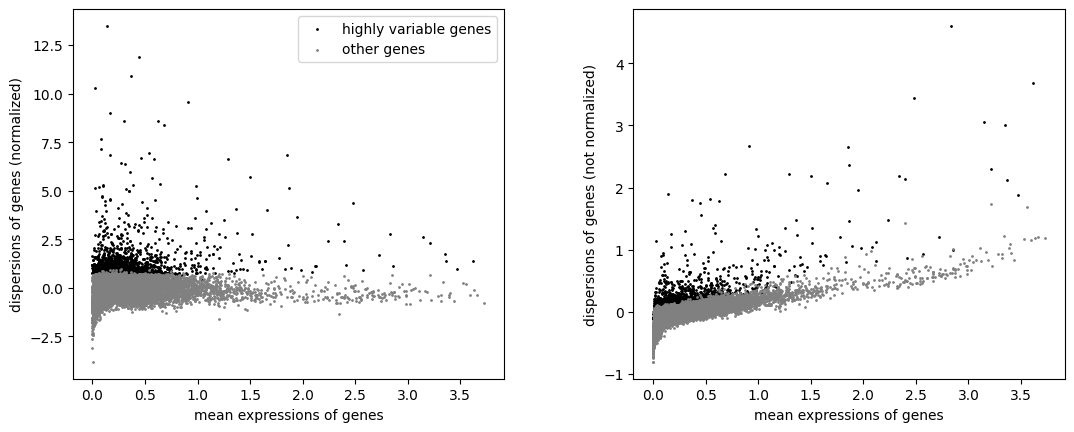

In [10]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(
    adata, n_top_genes=2000, batch_key="condition", flavor="seurat"
)
sc.pl.highly_variable_genes(adata)

adata = adata[:, adata.var["highly_variable"]].copy()

---

## 2. Subsampling & Visualization

In [11]:
X = pd.DataFrame(adata.X, index=adata.obs_names, columns=adata.var_names)
X = X.to_numpy()
y = pd.Series(adata.obs["condition"].values)

print(f"X shape (cells × genes): {X.shape[0]:,} × {X.shape[1]:,}")
print(f"y shape: {y.shape}")
print(f"Number of unique cell types in y: {np.unique(y)}")

X shape (cells × genes): 2,717 × 2,000
y shape: (2717,)
Number of unique cell types in y: ['d0' 'd2' 'd4' 'd7']


In [12]:
# Stratified subsampling
if SUBSAMPLE:
    if isinstance(subsample_size, float):
        subsample_size = int(subsample_size * X.shape[0])
    frac = subsample_size / X.shape[0]
    sss = StratifiedShuffleSplit(n_splits=1, test_size=frac, random_state=RANDOM_SEED)

    _, idx = next(sss.split(X, y))
    selected_idx = y.index[idx]

    X_sub = X[idx]
    y_sub = y.loc[selected_idx]

    X = X_sub
    y = y_sub

    print("X shape:", X.shape)

X shape: (1358, 2000)


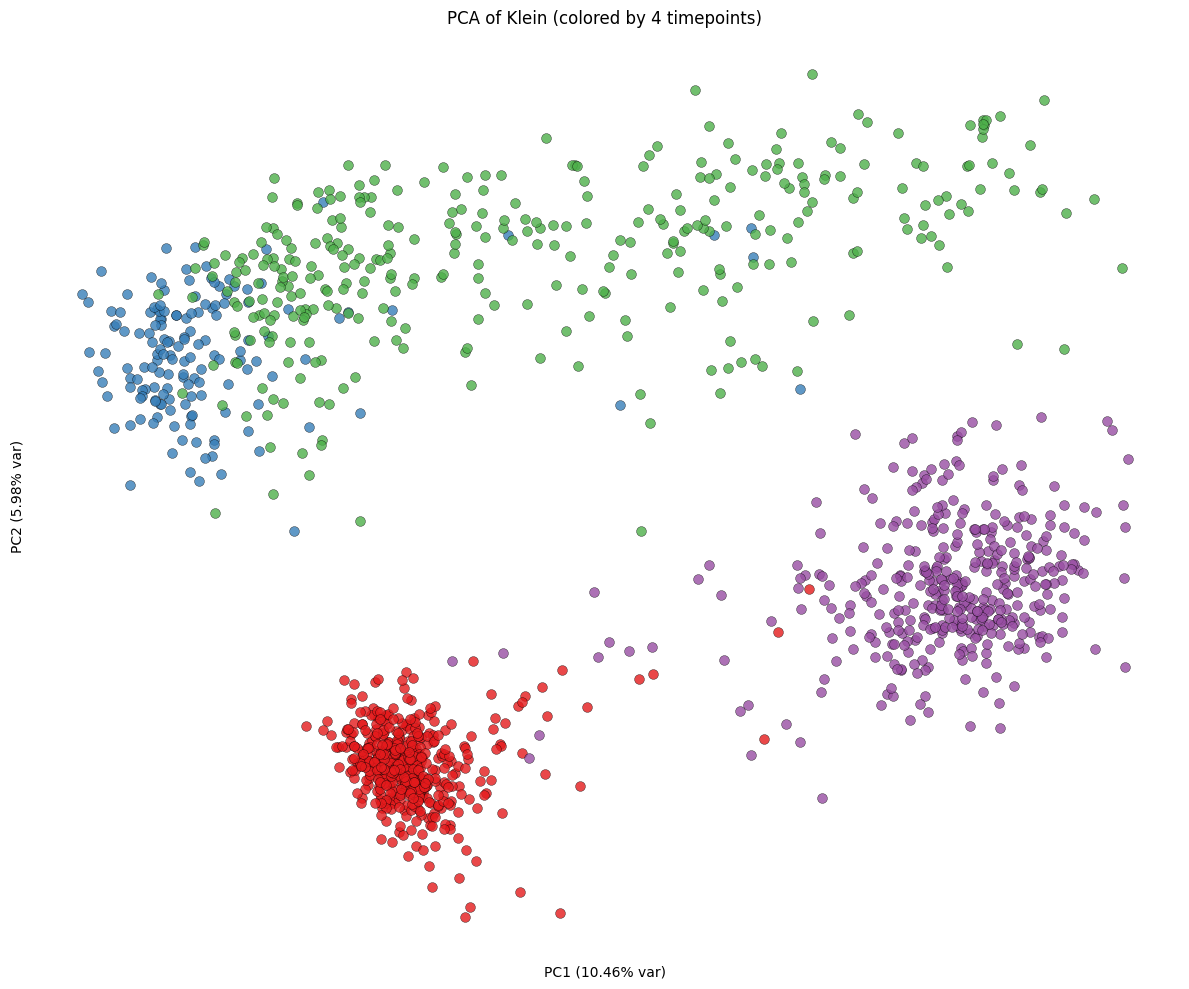

In [13]:
plot_dim_red(
    X=X, y=y, method="pca", show_legend=False,
    title="PCA of Klein (colored by 4 timepoints)"
)

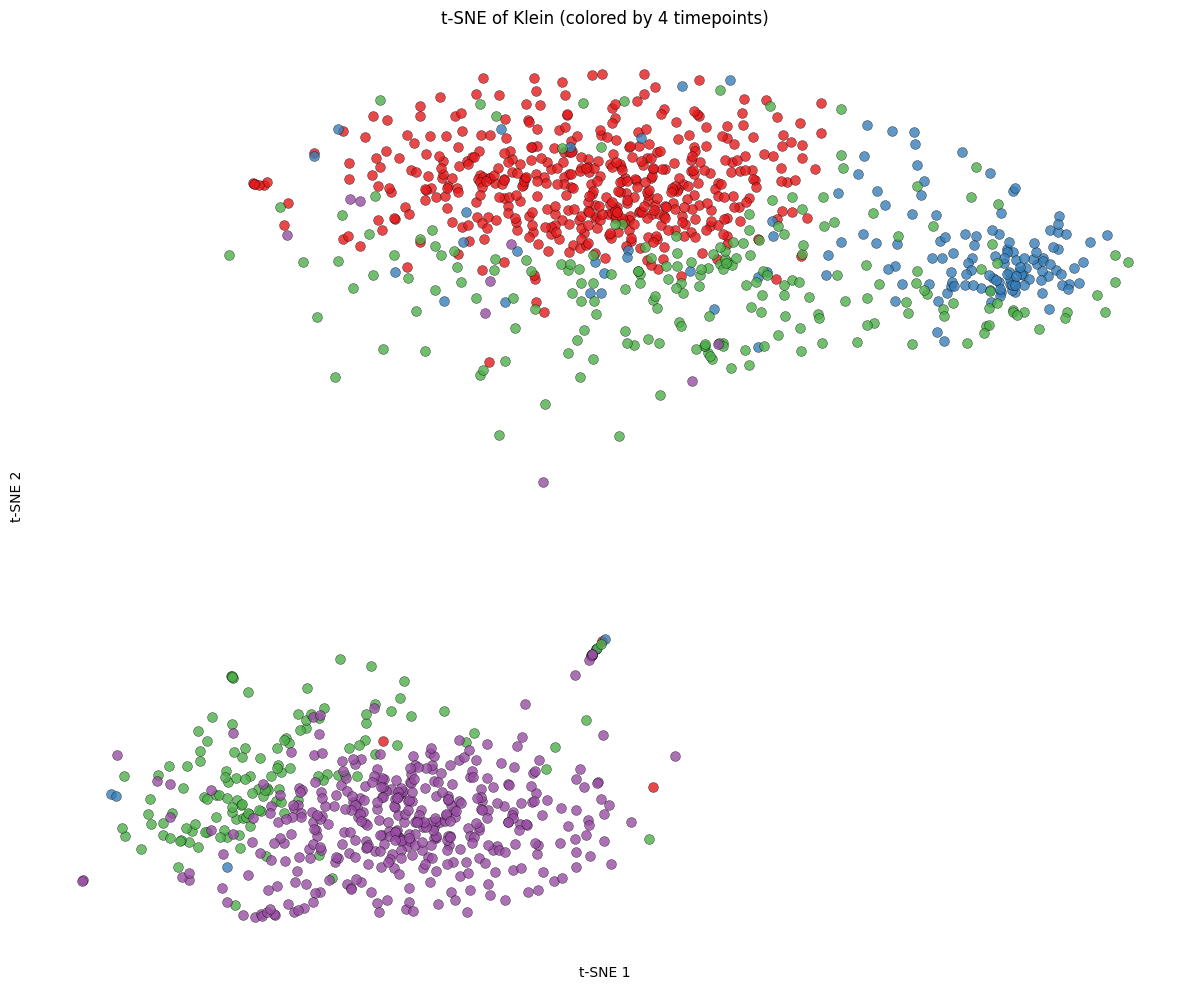

In [14]:
plot_dim_red(
    X=X, y=y, method="tsne", show_legend=False,
    title="t-SNE of Klein (colored by 4 timepoints)"
)

---

## 3. Baseline Metrics

We evaluate Silhouette, Gap statistic, Davies-Bouldin, and Calinski-Harabasz across k = 2, ..., K for Agglomerative (ward) and Spectral clustering:

In [15]:
ks = list(range(2, K + 1))

# gamma_005 = gamma_quantile_approx(X, q=0.05, random_state=RANDOM_SEED)
# gamma_01 = gamma_quantile_approx(X, q=0.10, random_state=RANDOM_SEED)
# gamma_05 = gamma_quantile_approx(X, q=0.50, random_state=RANDOM_SEED)

model_grids = [
    (AgglomerativeClustering, {"n_clusters": ks, "linkage": ["ward"]}),
    (SpectralClusteringCARVE, {"n_clusters": ks, "affinity": ["self_tuning"]}),
    # (SpectralClustering, {"n_clusters": ks, "gamma": [gamma_005, gamma_01, gamma_05]}),
]


baseline selections (max metric):
  - Silhouette: k=2, score=0.0990, ari=0.3899   [Agglomerative (linkage=ward)]
  - Gap Statistic: k=10, score=1.3060, ari=0.7504   [Agglomerative (linkage=ward)]
  - DB: k=2, score=0.2479, ari=0.3899   [Agglomerative (linkage=ward)]
  - CH: k=2, score=134.0480, ari=0.3899   [Agglomerative (linkage=ward)]


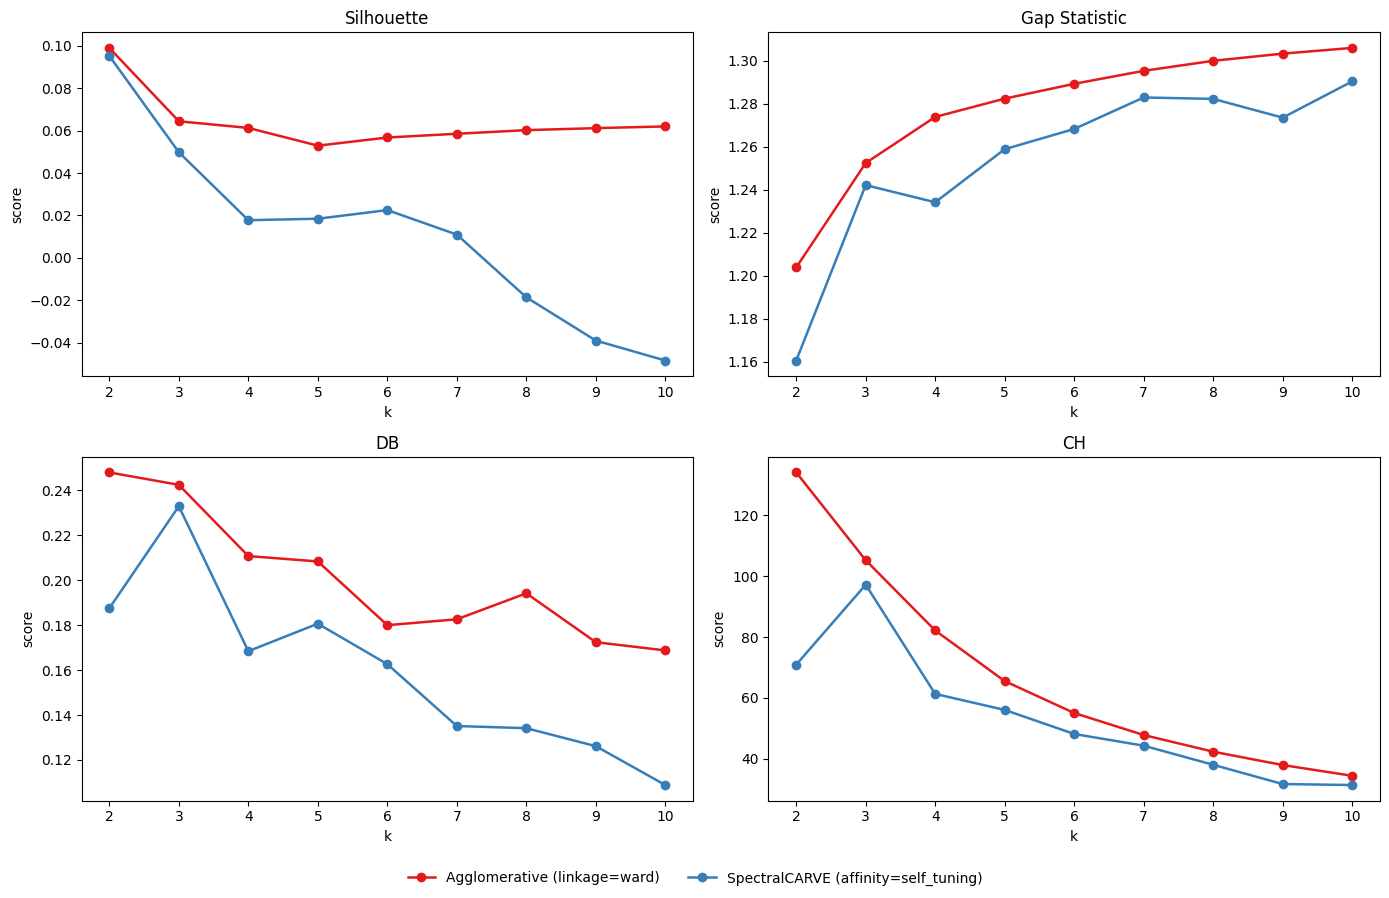

In [16]:
curves_df, best_df = baseline_metrics_over_k(
    X,
    y=y, 
    model_grids=model_grids, 
    metrics=["silhouette", "gap", "DB", "CH"],
    random_state=RANDOM_SEED,
    n_jobs=N_JOBS,
    ncols=2,
    figsize=(14, 9),
)

In [17]:
print("Best k selected by each metric:")
print(best_df[["metric", "best_model", "best_k", "best_ari"]].to_string(index=False))

Best k selected by each metric:
    metric                   best_model  best_k  best_ari
silhouette Agglomerative (linkage=ward)       2  0.389885
       gap Agglomerative (linkage=ward)      10  0.750409
        DB Agglomerative (linkage=ward)       2  0.389885
        CH Agglomerative (linkage=ward)       2  0.389885


---

## 4. CARVE Analysis

In [18]:
carve_path = Path("./carve_state_saves/carve_klein.carve")

if not carve_path.is_file():
    carve = CARVE(
        estimator_param_grids=model_grids, n_jobs=N_JOBS, random_state=RANDOM_SEED
    )
    carve.fit(X, reference_labels=y)

    # Save fitted state to avoid re-running
    carve_path.parent.mkdir(parents=True, exist_ok=True)
    carve.save(str(carve_path))
    print(f"Saved CARVE state to {carve_path}")
else:
    print(f"Loading CARVE state from {carve_path}")
    carve = CARVE.load(str(carve_path))
    carve.X_ = X

Loading CARVE state from carve_state_saves/carve_klein.carve


/Users/kaiwycik/GitHub/ClusteringValidation/code/src/carve/_plotting.py:282: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


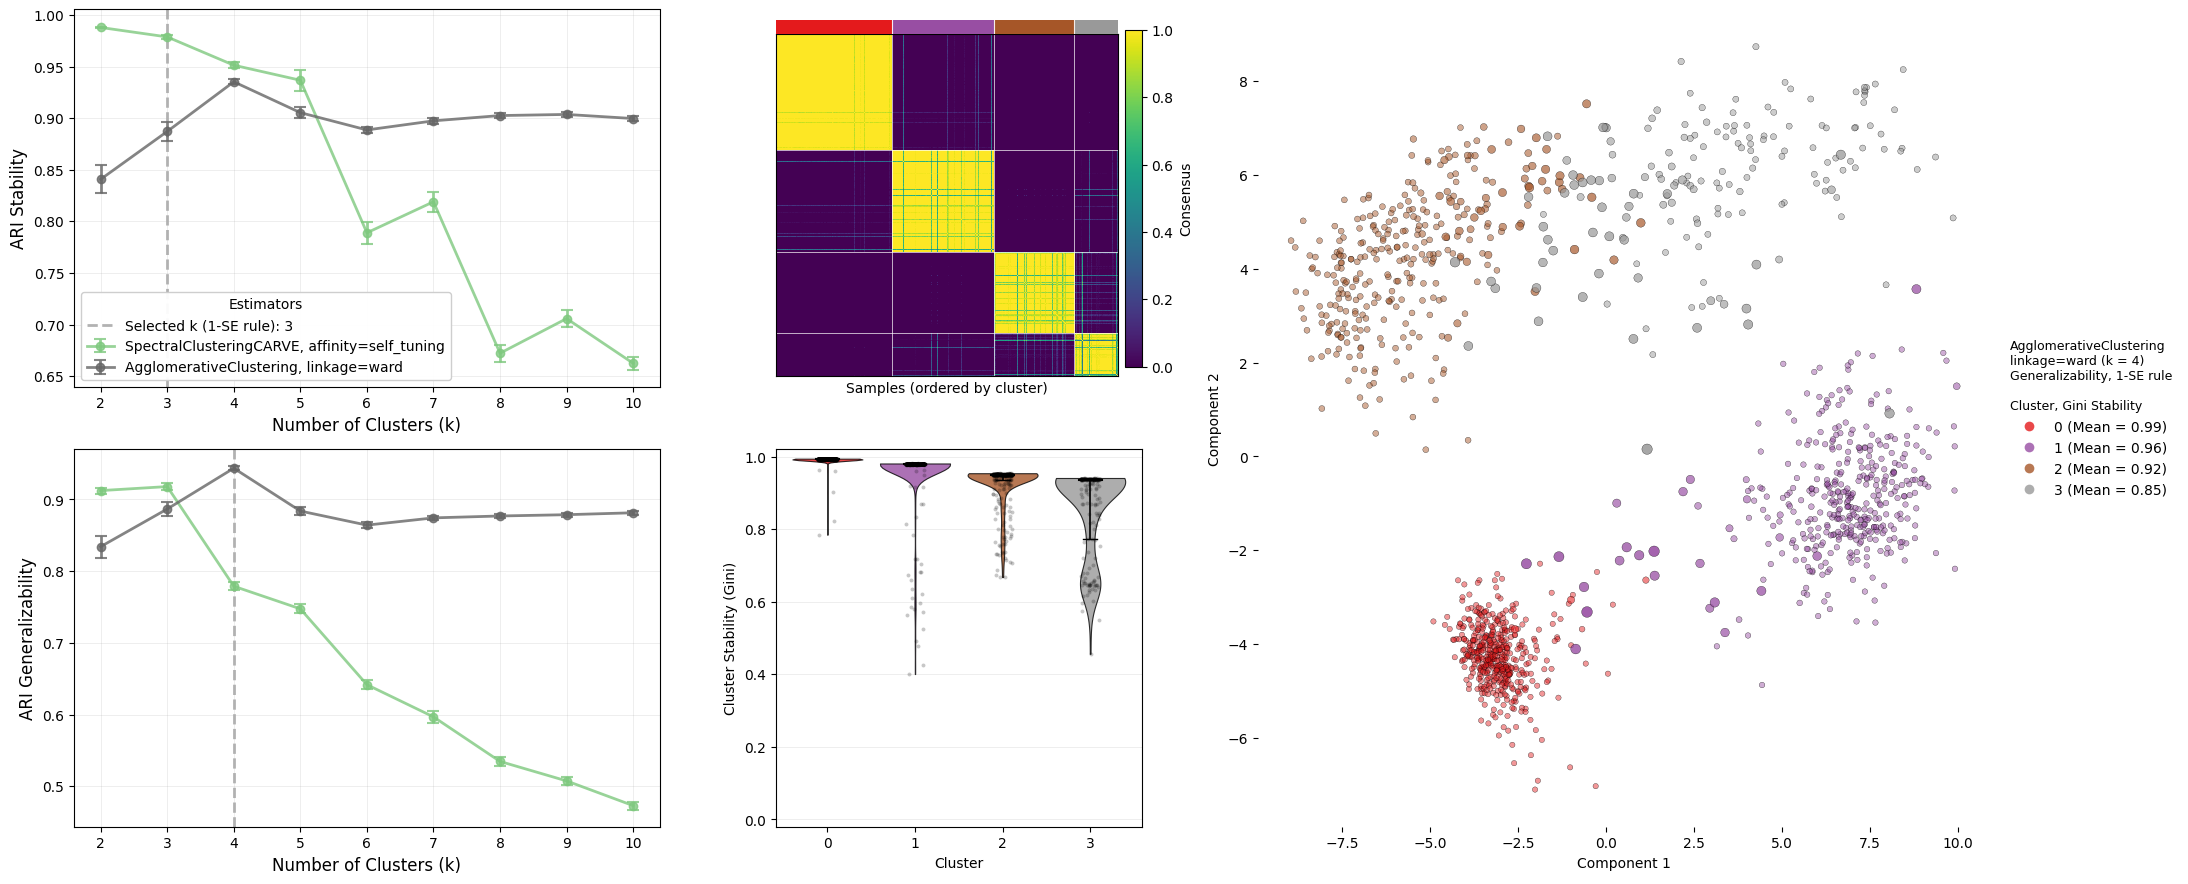

In [19]:
fig = plt.figure(figsize=(22, 9), constrained_layout=True)
gs = fig.add_gridspec(2, 3, width_ratios=[1.6, 1.0, 2.0])
ax_l1 = fig.add_subplot(gs[0, 0])
ax_l2 = fig.add_subplot(gs[1, 0])
ax_m1 = fig.add_subplot(gs[0, 1])
ax_m2 = fig.add_subplot(gs[1, 1])
ax_r = fig.add_subplot(gs[:, 2])

carve.plot_metric_over_n_clusters(measure='stability', rule=RULE, not_two=NOT_TWO, ax=ax_l1)
carve.plot_metric_over_n_clusters(measure='generalizability', rule=RULE, not_two=NOT_TWO, ax=ax_l2, legend=False)

carve.plot_consensus_matrix(measure='generalizability', rule=RULE, not_two=NOT_TWO, ax=ax_m1, palette=PALETTE_NAME)
carve.plot_cluster_violin(measure='generalizability', rule=RULE, not_two=NOT_TWO, ax=ax_m2, annotation=False, palette=PALETTE_NAME)

carve.plot_cluster_scatter(
    measure='generalizability', rule=RULE, not_two=NOT_TWO,
    ax=ax_r, palette=PALETTE_NAME
)

plt.show()

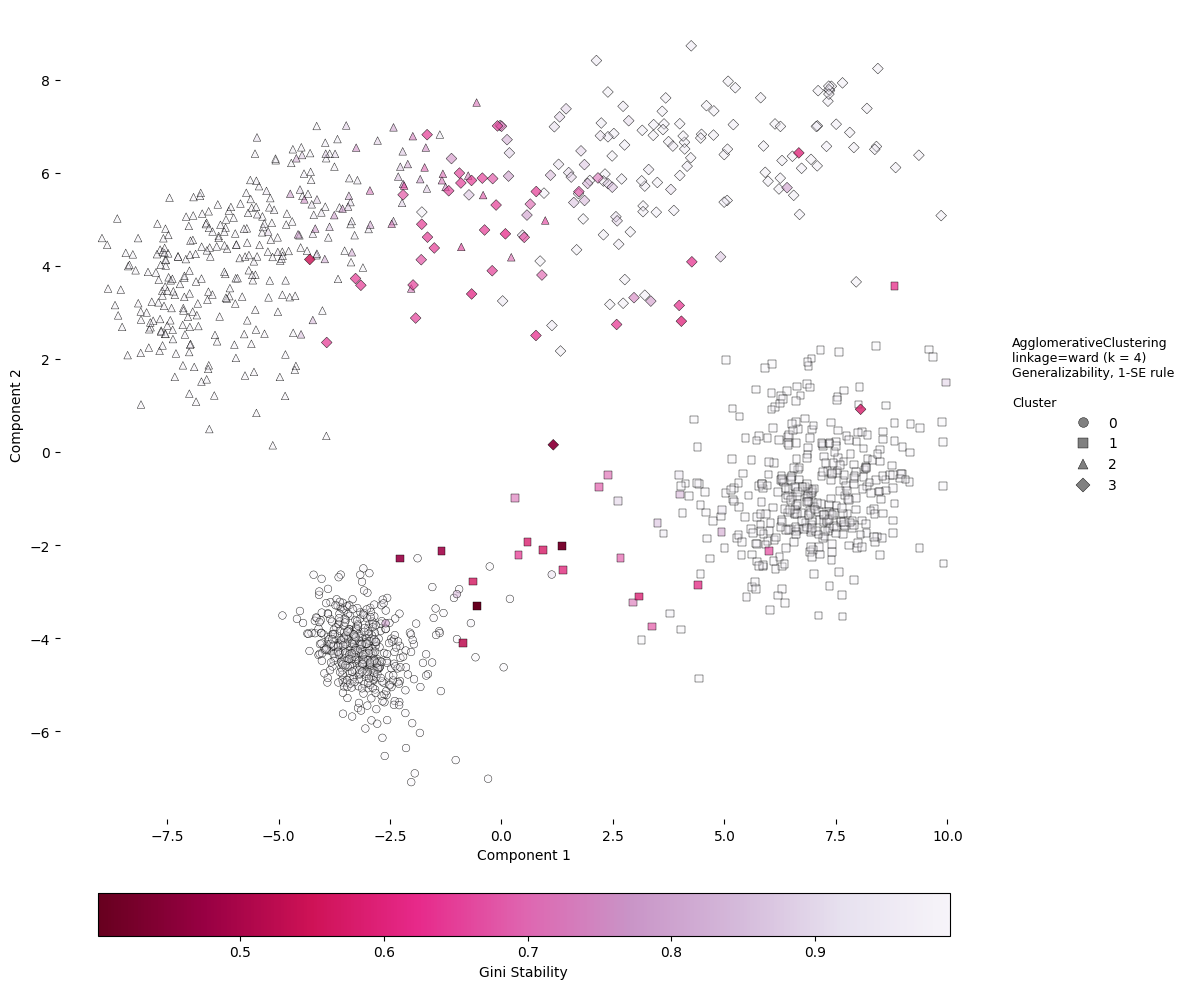

In [20]:
carve.plot_diagnostic_scatter(
    measure='generalizability', rule=RULE, not_two=NOT_TWO,
    cmap='PuRd_r', figsize=(12, 10)
)

plt.show()

In [21]:
print(
      f"CARVE selects k={carve.get_k(measure=MEASURE, rule=RULE, not_two=NOT_TWO)} "
      f"(measure={MEASURE}, rule={RULE}, not_two={NOT_TWO})"
)

CARVE selects k=4 (measure=g, rule=1se, not_two=True)


---

## 5. Quantitative Comparison

### 5.1 Composite Paper Figure (with ARI Comparison)

/Users/kaiwycik/GitHub/ClusteringValidation/code/notebooks/benchmarking_code/case_study_plotting.py:496: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


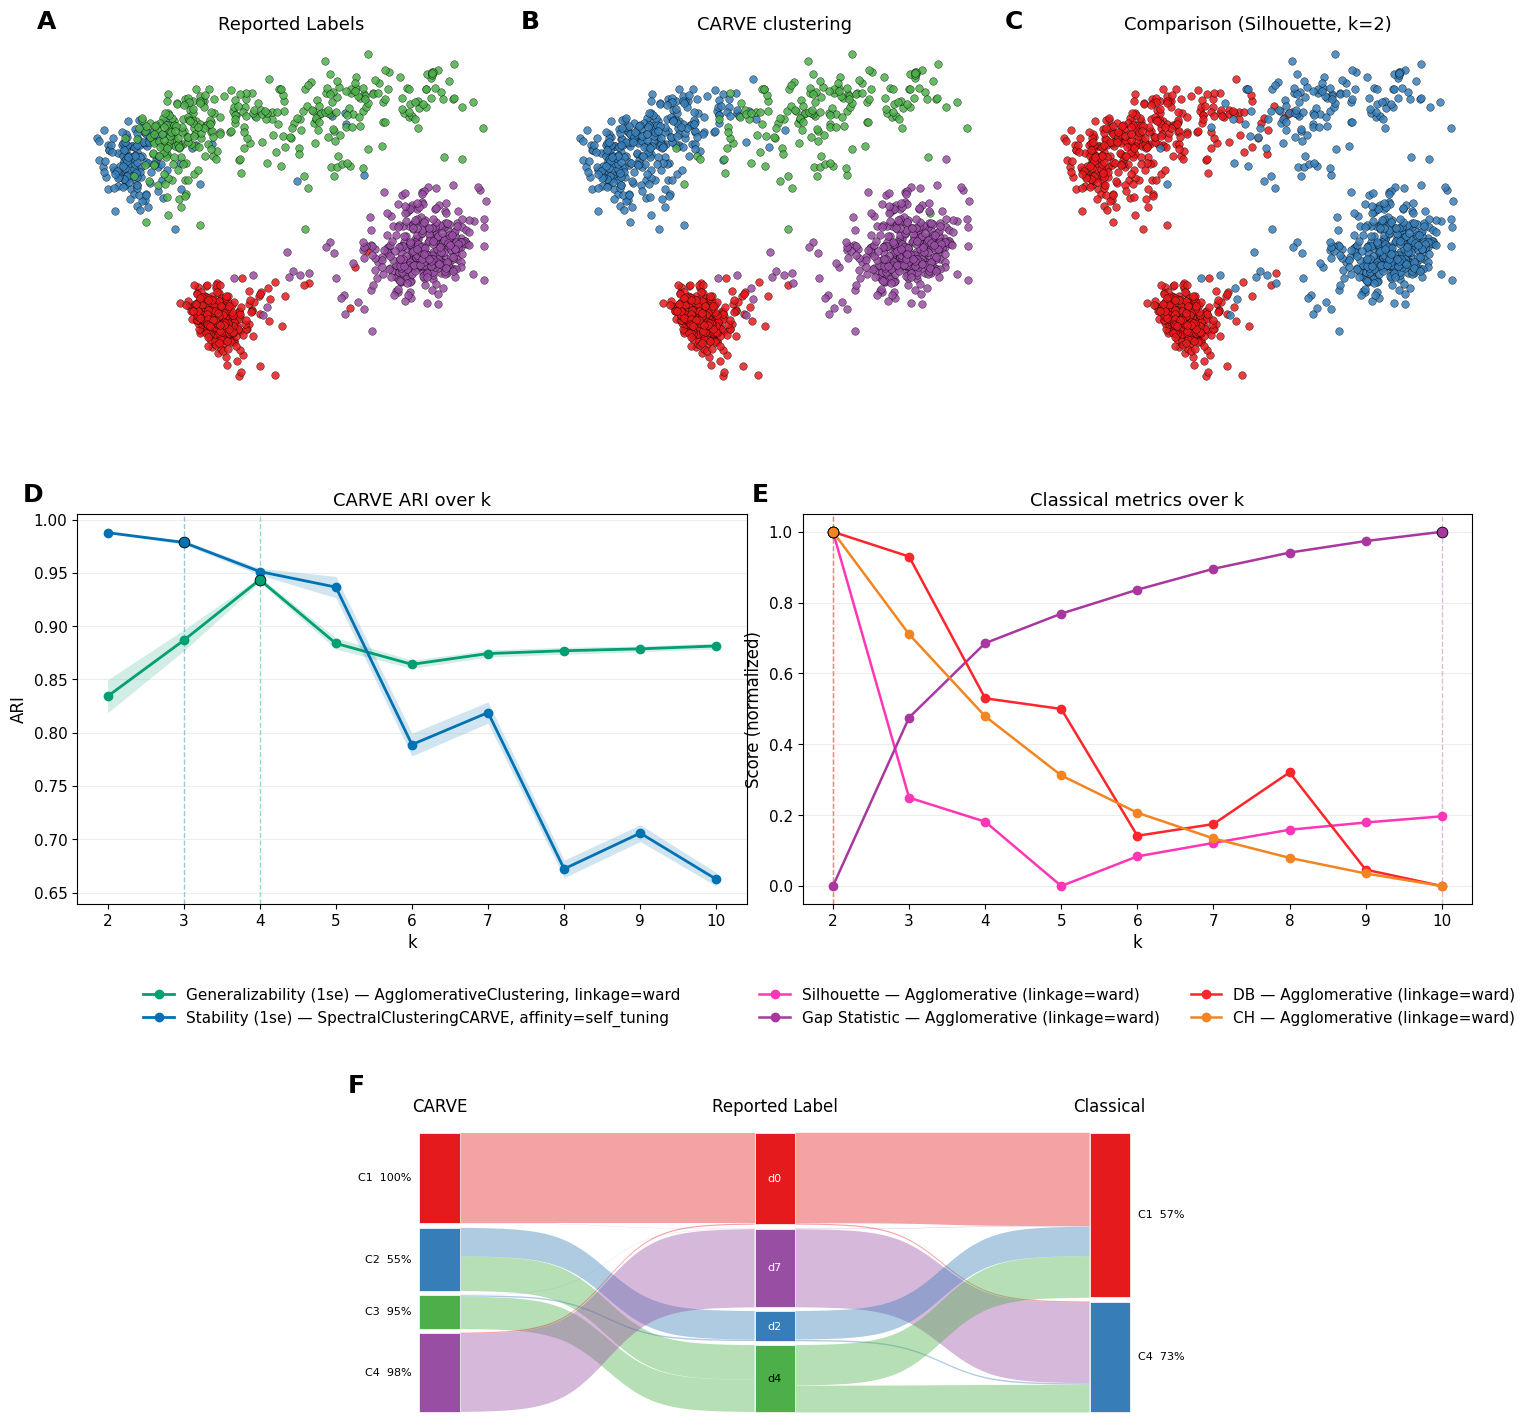

Comparison model used: Agglomerative (linkage=ward) (k=2)


In [22]:
# Choose baseline metric for panel C and alluvial right column
# options: "silhouette", "gap", "DB", "CH"
comparison_metric = "silhouette"

comparison_labels, comparison_model, comparison_k = build_baseline_best_labels(
    X=X,
    best_df=best_df,
    model_grids=model_grids,
    metric=comparison_metric,
    random_state=RANDOM_SEED,
)

# Map shorthand to names expected by plot_composite_figure
measure_map = {"s": "stability", "g": "generalizability"}
measure_for_plot = measure_map.get(MEASURE, MEASURE)

fig = plot_composite_figure(
    X=X,
    y=y.to_numpy() if hasattr(y, "to_numpy") else np.asarray(y),
    carve_obj=carve,
    curves_df=curves_df,
    best_df=best_df,
    comparison_labels=comparison_labels,
    measure=measure_for_plot,
    rule=RULE,
    not_two=NOT_TWO,
    consensus_type="stability",
    baseline_title=f"Comparison ({comparison_metric.title()}, k={comparison_k})",
    figsize=(18, 16),
)

plt.show()
print(f"Comparison model used: {comparison_model} (k={comparison_k})")

---

## 6. Summary

Klein et al. is a droplet-based scRNA-seq benchmark with 4 experimental timepoints (d0, d2, d4, d7) tracking mESC differentiation after LIF withdrawal. The high-dimensional gene expression profiles and progressive differentiation dynamics provide a setting where the number of meaningful clusters is debatable. We compare CARVE's generalizability-based selection (measure=g, rule=1se, not_two=True) against four classical metrics and quantify agreement with the 4 reported timepoint labels using ARI.

---